In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train_dir  = "/Users/nguyenngockimtuyet/AI_cuoiky/anh_cnn2"

In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [7]:
train_datagen=ImageDataGenerator(
    rescale=1.0/225,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [9]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 543 images belonging to 2 classes.


In [22]:
model_thitkho= Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation= 'softmax')
])

In [23]:
model_thitkho.compile(optimizer='adam',
                   loss='categorical_crossentropy',
               metrics=['accuracy'])
model_thitkho.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,780,034 (14.42 MB)

 Trainable params: 3,780,034 (14.42 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history=model_thitkho.fit(train_generator,epochs=200)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.6206 - loss: 0.6600
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7864 - loss: 0.4681
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 0.8250 - loss: 0.3943
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.8637 - loss: 0.3166
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.8711 - loss: 0.3139
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.8508 - loss: 0.3347
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.8564 - loss: 0.3125
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.8471 - loss: 0.3445
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.8011 - loss: 0.4017
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.8140 - loss: 0.3928
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.8490 - loss: 0.3720
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3

In [25]:
model_thitkho.save("model_thitkho1.h5")

In [1]:
from keras.models import load_model
model1 = load_model("/Users/nguyenngockimtuyet/AI_cuoiky/model_thitkho1.h5")

In [2]:
import cv2

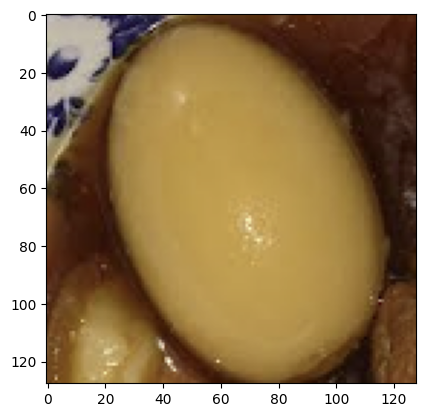

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Món tiên đoán: Trung-trong-thit-kho
Độ tự tin: 97.96%


In [13]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_cuoiky/Ảnh màn hình 2026-06-21 lúc 22.18.32.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

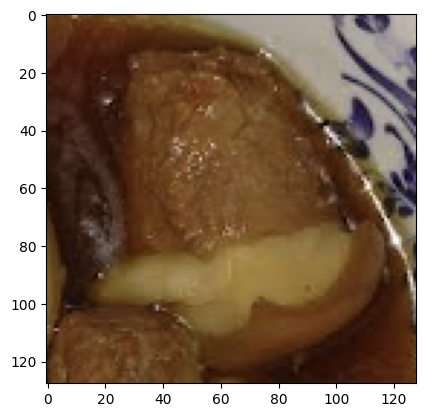

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Món tiên đoán: Thit-kho-khong trung
Độ tự tin: 95.95%


In [14]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_cuoiky/Ảnh màn hình 2026-06-21 lúc 22.22.38.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

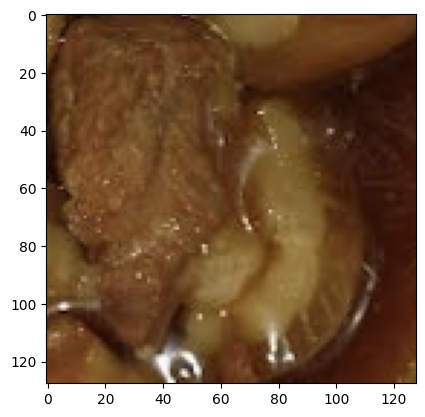

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Món tiên đoán: Thit-kho-khong trung
Độ tự tin: 98.15%


In [15]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_cuoiky/Ảnh màn hình 2026-06-21 lúc 22.22.53.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 128, 128, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Món tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")